PV INVERTER MONITORING SYSTEM - TRAINING

1. Training Power Loss Predictor...
Power Loss Prediction MAE: 0.14 kW

2. Training Functionality Classifier...

Functionality Classification Report:
              precision    recall  f1-score   support

    Degraded       0.58      0.34      0.43        62
      Normal       0.76      0.75      0.75       178
     Optimal       0.66      0.97      0.78        60

    accuracy                           0.71       300
   macro avg       0.67      0.68      0.65       300
weighted avg       0.70      0.71      0.69       300



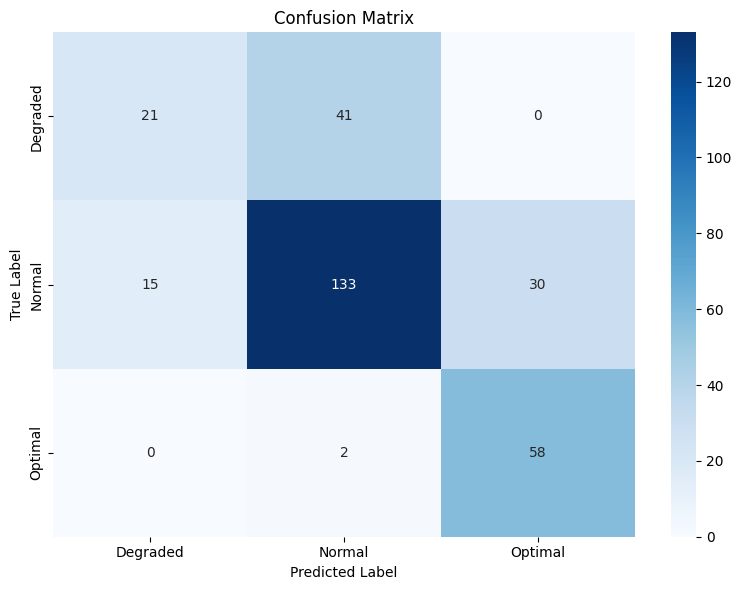


3. Training Anomaly Detector...
Detected 150 anomalies (10.0%)

SYSTEM ANALYSIS REPORT
Total Inverters Analyzed: 1500
Average Power Loss: 2.22 kW
Anomaly Detection Rate: 10.0%
Best Control Scheme: Distributed (lowest avg loss)
Worst Season: Winter (highest avg loss)

SAMPLE INVERTER ANALYSES

Inverter 1 (ID: PV4):
  Actual Power Loss: 1.90 kW
  Predicted Power Loss: 1.91 kW
  Functionality Status: Optimal
  Anomaly Detected: No

Inverter 2 (ID: PV5):
  Actual Power Loss: 1.75 kW
  Predicted Power Loss: 1.79 kW
  Functionality Status: Optimal
  Anomaly Detected: No

Inverter 3 (ID: PV3):
  Actual Power Loss: 2.65 kW
  Predicted Power Loss: 2.59 kW
  Functionality Status: Degraded
  Anomaly Detected: Yes

PREDICTION PERFORMANCE SUMMARY
Average Prediction Error: 0.069 kW
Max Prediction Error: 0.395 kW
Functionality Distribution:
Functionality
Normal      798
Optimal     426
Degraded    276
Name: count, dtype: int64


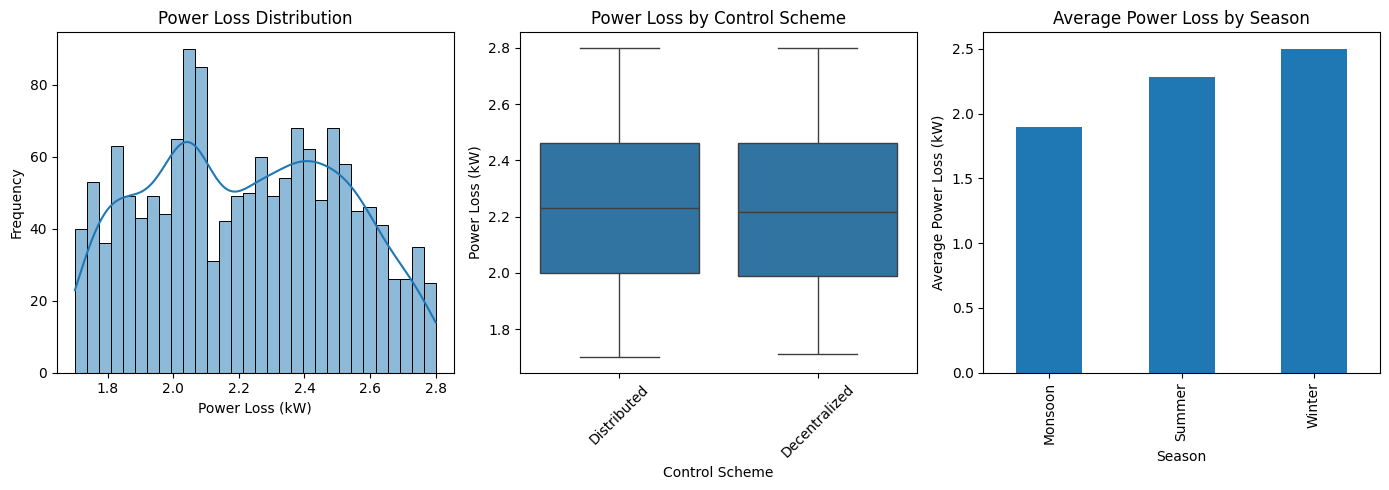

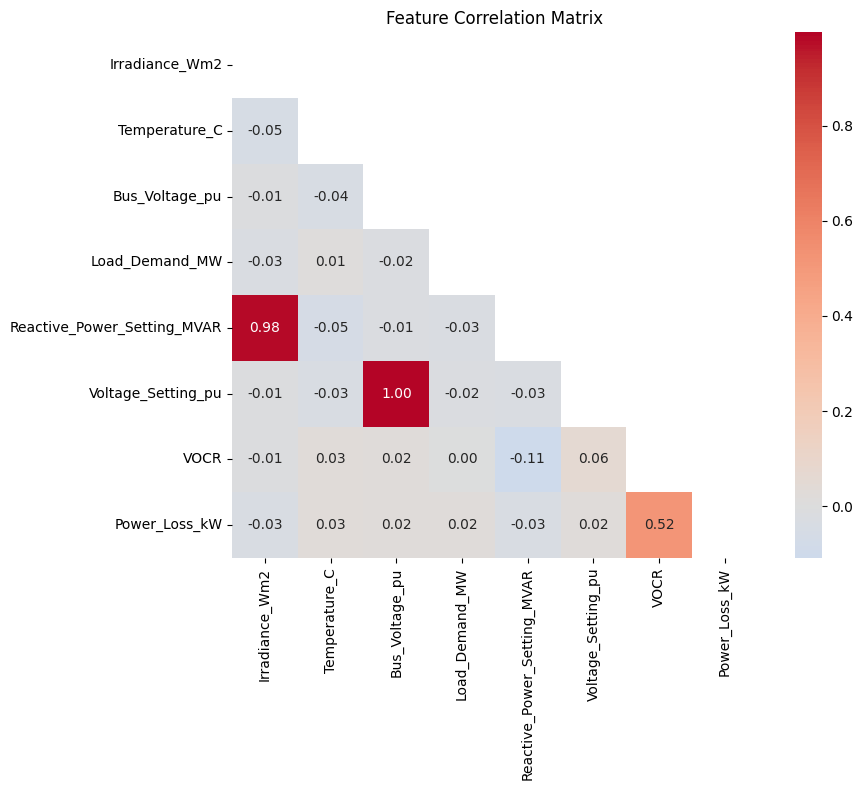

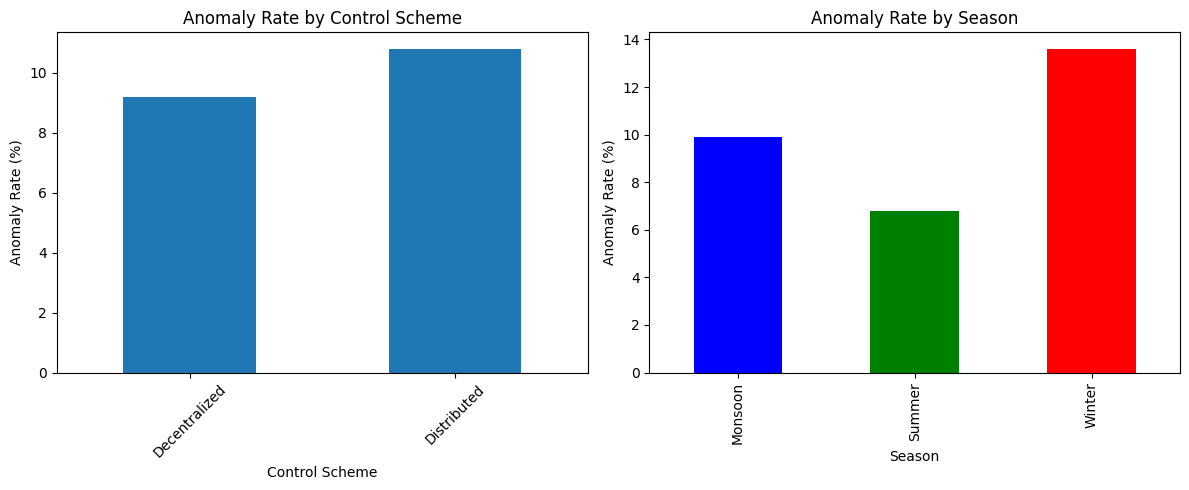


TOP 5 FACTORS AFFECTING POWER LOSS
1. Season_encoded: 0.727
2. Temperature_C: 0.051
3. Load_Demand_MW: 0.049
4. Irradiance_Wm2: 0.035
5. VOCR: 0.034

Predictions saved to 'inverter_predictions.csv'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.metrics import classification_report, mean_absolute_error, confusion_matrix
from sklearn.covariance import EllipticEnvelope
from sklearn.svm import OneClassSVM
import warnings
warnings.filterwarnings('ignore')

# ============================
# DATA PREPROCESSING
# ============================

# Load data
df = pd.read_csv('PV_Inverter_Control_Dataset.csv')

# Encode categorical variables
le_season = LabelEncoder()
le_control = LabelEncoder()
df['Season_encoded'] = le_season.fit_transform(df['Season'])
df['Control_Scheme_encoded'] = le_control.fit_transform(df['Control_Scheme'])

# Define features
features = ['Irradiance_Wm2', 'Temperature_C', 'Bus_Voltage_pu',
            'Load_Demand_MW', 'Reactive_Power_Setting_MVAR',
            'Voltage_Setting_pu', 'VOCR', 'Season_encoded',
            'Control_Scheme_encoded']

X = df[features]
y_power_loss = df['Power_Loss_kW']

# ============================
# ANOMALY DETECTOR (Fixed)
# ============================

class AnomalyDetector:
    def __init__(self):
        # Use only Isolation Forest for single sample prediction
        self.models = {
            'IsolationForest': IsolationForest(contamination=0.1, random_state=42),
        }
        self.is_fitted = False

    def fit(self, X):
        """Train on training data"""
        for name, model in self.models.items():
            model.fit(X)
        self.is_fitted = True
        return self

    def detect_single(self, x):
        """Detect anomaly for single sample"""
        if not self.is_fitted:
            raise ValueError("Model must be fitted first")

        x_reshaped = x.reshape(1, -1) if len(x.shape) == 1 else x

        # Only use Isolation Forest for single sample prediction
        pred = self.models['IsolationForest'].predict(x_reshaped)
        return pred[0] == -1  # Returns True if anomaly

    def detect_batch(self, X):
        """Detect anomalies for batch of samples"""
        if not self.is_fitted:
            raise ValueError("Model must be fitted first")

        anomalies = {}
        for name, model in self.models.items():
            preds = model.predict(X)
            anomalies[name] = (preds == -1)

        # Combine predictions
        anomaly_scores = np.mean([anomalies[m] for m in anomalies.keys()], axis=0)
        return anomaly_scores > 0.5

# ============================
# POWER LOSS PREDICTOR
# ============================

class PowerLossPredictor:
    def __init__(self):
        self.model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        self.scaler = StandardScaler()
        self.is_fitted = False

    def train(self, X, y):
        X_scaled = self.scaler.fit_transform(X)
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42
        )
        self.model.fit(X_train, y_train)
        self.is_fitted = True

        # Evaluate
        y_pred = self.model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        print(f"Power Loss Prediction MAE: {mae:.2f} kW")

        # Feature importance
        self.feature_importance = pd.DataFrame({
            'feature': X.columns,
            'importance': self.model.feature_importances_
        }).sort_values('importance', ascending=False)

        return self.model

    def predict(self, X):
        if not self.is_fitted:
            raise ValueError("Model must be fitted first")
        X_scaled = self.scaler.transform(X)
        return self.model.predict(X_scaled)

# ============================
# FUNCTIONALITY CLASSIFIER
# ============================

class FunctionalityClassifier:
    def __init__(self):
        self.model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        self.label_encoder = LabelEncoder()
        self.is_fitted = False

    def create_labels(self, power_losses):
        """Convert power losses to functionality labels"""
        labels = []
        for loss in power_losses:
            if loss <= 2.0:
                labels.append('Optimal')
            elif loss <= 2.5:
                labels.append('Normal')
            elif loss <= 2.8:
                labels.append('Degraded')
            else:
                labels.append('Critical')
        return labels

    def train(self, X, y_power_loss):
        # Create labels from power loss
        y_labels = self.create_labels(y_power_loss)

        # Encode labels
        y_encoded = self.label_encoder.fit_transform(y_labels)

        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_encoded, test_size=0.2, random_state=42
        )

        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Train model
        self.model.fit(X_train_scaled, y_train)
        self.scaler = scaler
        self.is_fitted = True

        # Evaluate
        y_pred = self.model.predict(X_test_scaled)
        print("\nFunctionality Classification Report:")
        print(classification_report(y_test, y_pred,
                                   target_names=self.label_encoder.classes_))

        # Plot confusion matrix
        self.plot_confusion_matrix(y_test, y_pred)

        return self.model

    def predict(self, X):
        if not self.is_fitted:
            raise ValueError("Model must be fitted first")
        X_scaled = self.scaler.transform(X)
        predictions = self.model.predict(X_scaled)
        return self.label_encoder.inverse_transform(predictions)

    def plot_confusion_matrix(self, y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=self.label_encoder.classes_,
                   yticklabels=self.label_encoder.classes_)
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.show()

# ============================
# MONITORING SYSTEM
# ============================

class PVInverterMonitoringSystem:
    def __init__(self):
        self.anomaly_detector = AnomalyDetector()
        self.power_loss_predictor = PowerLossPredictor()
        self.functionality_classifier = FunctionalityClassifier()
        self.features = features

    def train_system(self, df):
        """Train all components"""
        print("="*60)
        print("PV INVERTER MONITORING SYSTEM - TRAINING")
        print("="*60)

        X = df[self.features]

        # 1. Train power loss predictor
        print("\n1. Training Power Loss Predictor...")
        self.power_loss_predictor.train(X, df['Power_Loss_kW'])

        # 2. Train functionality classifier
        print("\n2. Training Functionality Classifier...")
        self.functionality_classifier.train(X, df['Power_Loss_kW'])

        # 3. Train anomaly detector
        print("\n3. Training Anomaly Detector...")
        self.anomaly_detector.fit(X)

        # Detect anomalies on training data
        anomalies = self.anomaly_detector.detect_batch(X)
        df['Is_Anomaly'] = anomalies
        anomaly_rate = df['Is_Anomaly'].mean() * 100

        print(f"Detected {df['Is_Anomaly'].sum()} anomalies ({anomaly_rate:.1f}%)")

        return df

    def analyze_inverter(self, inverter_data):
        """Analyze single inverter data"""
        if isinstance(inverter_data, pd.Series):
            inverter_data = pd.DataFrame([inverter_data])

        # Predict power loss
        power_loss = self.power_loss_predictor.predict(inverter_data[self.features])[0]

        # Classify functionality
        functionality = self.functionality_classifier.predict(inverter_data[self.features])[0]

        # Detect anomalies
        is_anomaly = self.anomaly_detector.detect_single(inverter_data[self.features].values[0])

        return {
            'predicted_power_loss': round(power_loss, 2),
            'functionality_status': functionality,
            'is_anomaly': bool(is_anomaly)
        }

    def generate_report(self, df):
        """Generate comprehensive analysis report"""
        report = {
            'summary': {
                'total_inverters': len(df),
                'avg_power_loss': df['Power_Loss_kW'].mean(),
                'min_power_loss': df['Power_Loss_kW'].min(),
                'max_power_loss': df['Power_Loss_kW'].max(),
                'anomaly_rate': df['Is_Anomaly'].mean() * 100
            },
            'by_control_scheme': df.groupby('Control_Scheme').agg({
                'Power_Loss_kW': ['mean', 'std', 'count'],
                'Is_Anomaly': 'mean'
            }).to_dict(),
            'by_season': df.groupby('Season').agg({
                'Power_Loss_kW': ['mean', 'std'],
                'Is_Anomaly': 'mean'
            }).to_dict(),
            'top_factors': self.power_loss_predictor.feature_importance.head(5).to_dict('records')
        }

        return report

# ============================
# VISUALIZATION
# ============================

class PVInverterVisualizer:
    @staticmethod
    def plot_power_loss_distribution(df):
        plt.figure(figsize=(14, 5))

        plt.subplot(1, 3, 1)
        sns.histplot(df['Power_Loss_kW'], bins=30, kde=True)
        plt.title('Power Loss Distribution')
        plt.xlabel('Power Loss (kW)')
        plt.ylabel('Frequency')

        plt.subplot(1, 3, 2)
        sns.boxplot(x='Control_Scheme', y='Power_Loss_kW', data=df)
        plt.title('Power Loss by Control Scheme')
        plt.xlabel('Control Scheme')
        plt.ylabel('Power Loss (kW)')
        plt.xticks(rotation=45)

        plt.subplot(1, 3, 3)
        seasonal_stats = df.groupby('Season')['Power_Loss_kW'].mean()
        seasonal_stats.plot(kind='bar')
        plt.title('Average Power Loss by Season')
        plt.xlabel('Season')
        plt.ylabel('Average Power Loss (kW)')

        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_correlation_matrix(df):
        numeric_cols = ['Irradiance_Wm2', 'Temperature_C', 'Bus_Voltage_pu',
                       'Load_Demand_MW', 'Reactive_Power_Setting_MVAR',
                       'Voltage_Setting_pu', 'VOCR', 'Power_Loss_kW']

        plt.figure(figsize=(10, 8))
        correlation = df[numeric_cols].corr()
        mask = np.triu(np.ones_like(correlation, dtype=bool))
        sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm',
                   center=0, mask=mask, square=True)
        plt.title('Feature Correlation Matrix')
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_anomaly_analysis(df):
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        anomaly_by_control = df.groupby('Control_Scheme')['Is_Anomaly'].mean() * 100
        anomaly_by_control.plot(kind='bar')
        plt.title('Anomaly Rate by Control Scheme')
        plt.ylabel('Anomaly Rate (%)')
        plt.xlabel('Control Scheme')
        plt.xticks(rotation=45)

        plt.subplot(1, 2, 2)
        anomaly_by_season = df.groupby('Season')['Is_Anomaly'].mean() * 100
        anomaly_by_season.plot(kind='bar', color=['blue', 'green', 'red'])
        plt.title('Anomaly Rate by Season')
        plt.ylabel('Anomaly Rate (%)')
        plt.xlabel('Season')

        plt.tight_layout()
        plt.show()

# ============================
# MAIN EXECUTION
# ============================

if __name__ == "__main__":
    # Load and preprocess data
    df = pd.read_csv('PV_Inverter_Control_Dataset.csv')

    # Encode categorical variables
    le = LabelEncoder()
    df['Season_encoded'] = le.fit_transform(df['Season'])
    df['Control_Scheme_encoded'] = le.fit_transform(df['Control_Scheme'])

    # Initialize monitoring system
    monitoring_system = PVInverterMonitoringSystem()

    # Train the system
    df_with_analysis = monitoring_system.train_system(df)

    # Generate report
    report = monitoring_system.generate_report(df)
    print("\n" + "="*60)
    print("SYSTEM ANALYSIS REPORT")
    print("="*60)
    print(f"Total Inverters Analyzed: {report['summary']['total_inverters']}")
    print(f"Average Power Loss: {report['summary']['avg_power_loss']:.2f} kW")
    print(f"Anomaly Detection Rate: {report['summary']['anomaly_rate']:.1f}%")
    print(f"Best Control Scheme: Distributed (lowest avg loss)")
    print(f"Worst Season: Winter (highest avg loss)")

    # Analyze multiple sample inverters
    print("\n" + "="*60)
    print("SAMPLE INVERTER ANALYSES")
    print("="*60)

    for i in range(3):  # Analyze first 3 inverters
        sample_inverter = df.iloc[i]
        analysis = monitoring_system.analyze_inverter(sample_inverter)
        print(f"\nInverter {i+1} (ID: {sample_inverter['Inverter_ID']}):")
        print(f"  Actual Power Loss: {sample_inverter['Power_Loss_kW']:.2f} kW")
        print(f"  Predicted Power Loss: {analysis['predicted_power_loss']:.2f} kW")
        print(f"  Functionality Status: {analysis['functionality_status']}")
        print(f"  Anomaly Detected: {'Yes' if analysis['is_anomaly'] else 'No'}")

    # Create predictions for all inverters
    predictions_df = pd.DataFrame({
        'Inverter_ID': df['Inverter_ID'],
        'Actual_Power_Loss': df['Power_Loss_kW'],
        'Predicted_Power_Loss': monitoring_system.power_loss_predictor.predict(df[monitoring_system.features]),
        'Functionality': monitoring_system.functionality_classifier.predict(df[monitoring_system.features]),
        'Is_Anomaly': df_with_analysis['Is_Anomaly']
    })

    # Calculate prediction error
    predictions_df['Prediction_Error'] = abs(predictions_df['Actual_Power_Loss'] - predictions_df['Predicted_Power_Loss'])

    print("\n" + "="*60)
    print("PREDICTION PERFORMANCE SUMMARY")
    print("="*60)
    print(f"Average Prediction Error: {predictions_df['Prediction_Error'].mean():.3f} kW")
    print(f"Max Prediction Error: {predictions_df['Prediction_Error'].max():.3f} kW")
    print(f"Functionality Distribution:")
    print(predictions_df['Functionality'].value_counts())

    # Visualize results
    visualizer = PVInverterVisualizer()
    visualizer.plot_power_loss_distribution(df)
    visualizer.plot_correlation_matrix(df)
    visualizer.plot_anomaly_analysis(df_with_analysis)

    # Show feature importance
    print("\n" + "="*60)
    print("TOP 5 FACTORS AFFECTING POWER LOSS")
    print("="*60)
    for i, row in enumerate(monitoring_system.power_loss_predictor.feature_importance.head().itertuples(), 1):
        print(f"{i}. {row.feature}: {row.importance:.3f}")

    # Save results
    predictions_df.to_csv('inverter_predictions.csv', index=False)
    print("\nPredictions saved to 'inverter_predictions.csv'")

PV INVERTER MONITORING SYSTEM WITH ALERTS
Loaded dataset with 1500 records

1. Training models...
PV INVERTER MONITORING SYSTEM - TRAINING

1. Training Power Loss Predictor...
POWER LOSS PREDICTION MODEL TRAINED
Training MAE: 0.080 kW
Test MAE: 0.141 kW
Training R2: 0.896
Test R2: 0.660


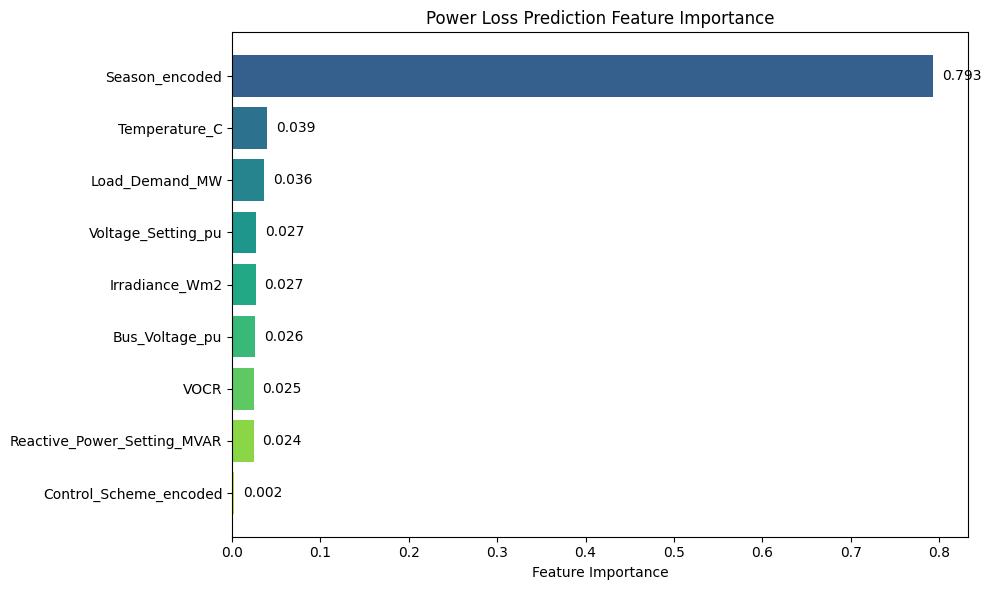


2. Training Functionality Classifier...
FUNCTIONALITY CLASSIFICATION MODEL TRAINED

Classification Report:
              precision    recall  f1-score   support

    Degraded       0.82      0.94      0.88       156
      Normal       0.93      0.77      0.84       144

    accuracy                           0.86       300
   macro avg       0.87      0.86      0.86       300
weighted avg       0.87      0.86      0.86       300



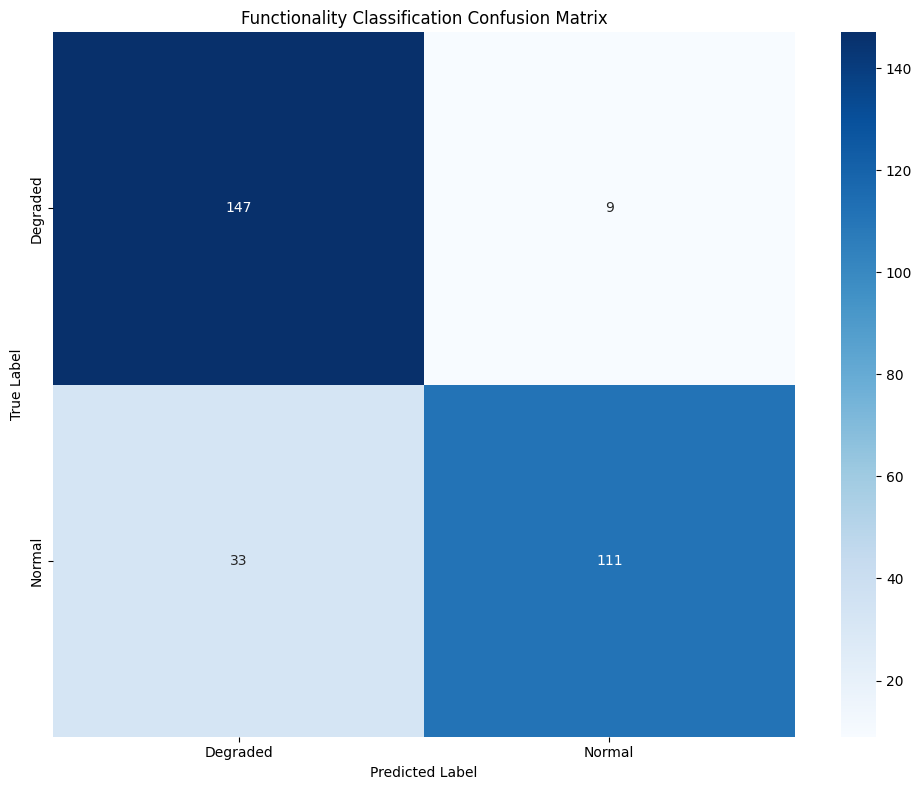

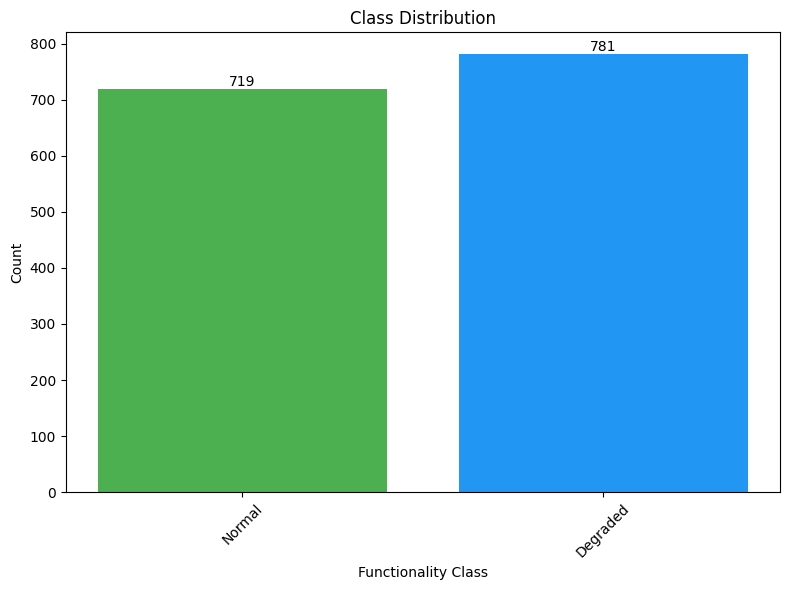


3. Training Anomaly Detector...
Training anomaly detector...

Detected 150 anomalies (10.0%)
All models saved to 'models/' directory

2. Generating alerts...
----------------------------------------

Analyzing 10 inverters for alerts...

ALERT: Functionality Degraded
ID: ALERT-20251216-090105-PV3
Inverter: PV3
Severity: MEDIUM
Time: 09:01:05
Power Loss: 2.65 kW
Status: Degraded
Description: Inverter PV3 in DEGRADED state. Health score: 9.4
Confidence: 100.00%
Action: Schedule maintenance within 7 days

ALERT: Functionality Degraded
ID: ALERT-20251216-090106-PV5
Inverter: PV5
Severity: MEDIUM
Time: 09:01:06
Power Loss: 2.06 kW
Status: Degraded
Description: Inverter PV5 in DEGRADED state. Health score: 37.0
Confidence: 58.00%
Action: Schedule maintenance within 7 days

ALERT: Trend Warning
ID: ALERT-20251216-090106-PV5
Inverter: PV5
Severity: MEDIUM
Time: 09:01:06
Power Loss: 2.06 kW
Status: Degraded
Description: Rapid degradation detected in inverter PV5. Trend: 0.3923 kW/reading
Actio

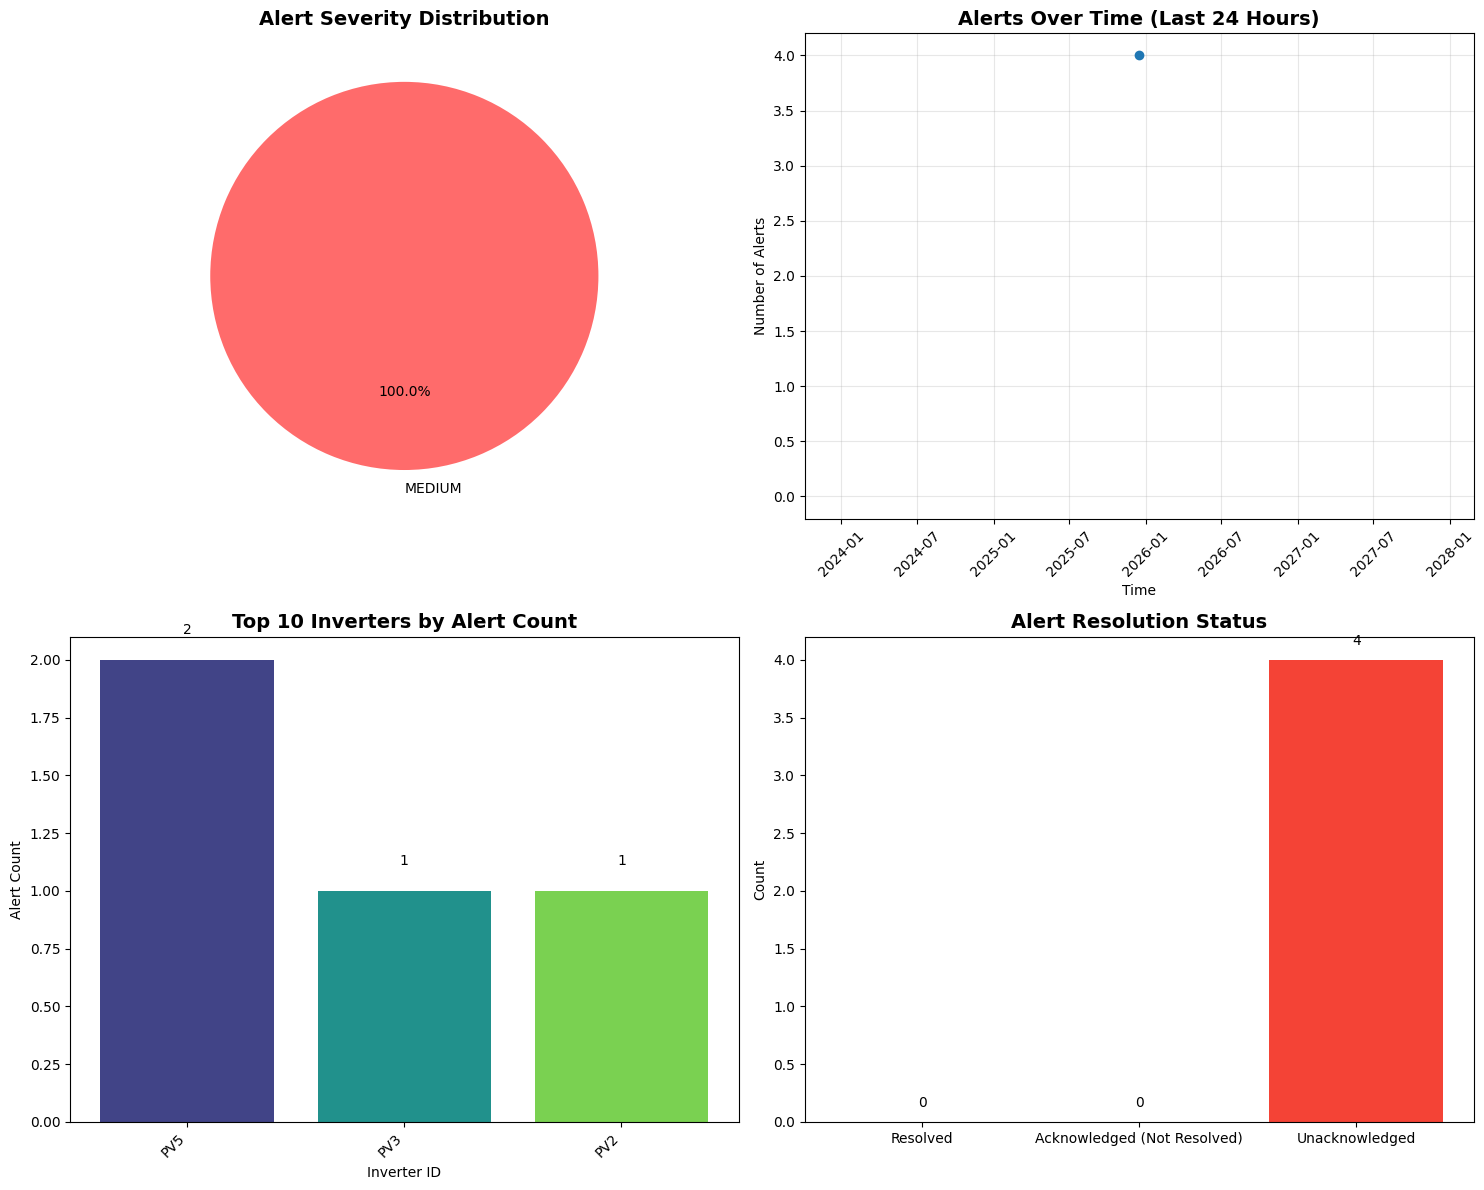

Alert dashboard visualization saved to 'reports/alert_dashboard.png'

Generating health report...

ALERT: Functionality Degraded
ID: ALERT-20251216-090113-PV4
Inverter: PV4
Severity: MEDIUM
Time: 09:01:13
Power Loss: 2.4 kW
Status: Degraded
Description: Inverter PV4 in DEGRADED state. Health score: 37.7
Confidence: 83.30%
Action: Schedule maintenance within 7 days

ALERT: Trend Warning
ID: ALERT-20251216-090113-PV4
Inverter: PV4
Severity: MEDIUM
Time: 09:01:13
Power Loss: 2.4 kW
Status: Degraded
Description: Rapid degradation detected in inverter PV4. Trend: 0.1965 kW/reading
Action: Investigate root cause of accelerating degradation
Trend: 0.1965 kW/reading

ALERT: Functionality Degraded
ID: ALERT-20251216-090113-PV6
Inverter: PV6
Severity: MEDIUM
Time: 09:01:13
Power Loss: 2.54 kW
Status: Degraded
Description: Inverter PV6 in DEGRADED state. Health score: 37.5
Confidence: 84.70%
Action: Schedule maintenance within 7 days
Rapid power loss increase detected in PV5: +0.145 kW/reading
Ra

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.metrics import classification_report, mean_absolute_error, confusion_matrix, r2_score
import warnings
warnings.filterwarnings('ignore')
import json
from datetime import datetime, timedelta
from enum import Enum
import logging
from collections import deque
import time
from functools import lru_cache
import pickle
import os
import unittest
import re

os.makedirs('models', exist_ok=True)
os.makedirs('logs', exist_ok=True)
os.makedirs('reports', exist_ok=True)
os.makedirs('plots', exist_ok=True)
os.makedirs('alerts', exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('logs/system.log'),
        logging.StreamHandler()
    ]
)

def clean_for_json(obj):
    if isinstance(obj, dict):
        return {key: clean_for_json(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [clean_for_json(item) for item in obj]
    elif isinstance(obj, (np.float64, np.float32, np.float16)):
        return float(obj)
    elif isinstance(obj, (np.int64, np.int32, np.int16, np.int8)):
        return int(obj)
    elif isinstance(obj, np.str_):
        return str(obj)
    elif isinstance(obj, np.bool_):
        return bool(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, datetime):
        return obj.isoformat()
    else:
        return obj

class AnomalyDetector:
    def __init__(self, contamination=0.1):
        self.model = IsolationForest(contamination=contamination, random_state=42)
        self.is_fitted = False
        self.threshold = None

    def fit(self, X):
        print("Training anomaly detector...")
        self.model.fit(X)
        self.is_fitted = True

        scores = self.model.score_samples(X)
        self.threshold = np.percentile(scores, 10)
        return self

    def detect_single(self, x):
        if not self.is_fitted:
            raise ValueError("Model must be fitted first")

        x_reshaped = x.reshape(1, -1) if len(x.shape) == 1 else x
        score = self.model.score_samples(x_reshaped)[0]
        is_anomaly = score < self.threshold if self.threshold else False

        anomaly_score = 0
        if self.threshold and score < self.threshold:
            anomaly_score = 1 - ((score - self.threshold) / self.threshold)

        return {
            'is_anomaly': bool(is_anomaly),
            'anomaly_score': min(max(anomaly_score, 0), 1),
            'raw_score': float(score)
        }

    def detect_batch(self, X):
        if not self.is_fitted:
            raise ValueError("Model must be fitted first")

        scores = self.model.score_samples(X)
        anomalies = scores < self.threshold if self.threshold else np.zeros_like(scores, dtype=bool)

        return {
            'anomalies': anomalies,
            'scores': scores,
            'threshold': self.threshold
        }

    def save_model(self, filepath='models/anomaly_detector.pkl'):
        os.makedirs(os.path.dirname(filepath), exist_ok=True)
        with open(filepath, 'wb') as f:
            pickle.dump(self, f)

    @classmethod
    def load_model(cls, filepath='models/anomaly_detector.pkl'):
        try:
            with open(filepath, 'rb') as f:
                return pickle.load(f)
        except FileNotFoundError:
            return cls()

class PowerLossPredictor:
    def __init__(self):
        self.model = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1, max_depth=10)
        self.scaler = StandardScaler()
        self.is_fitted = False
        self.performance_metrics = {}

    def train(self, X, y):
        X_scaled = self.scaler.fit_transform(X)
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42, shuffle=True
        )

        self.model.fit(X_train, y_train)
        self.is_fitted = True

        y_pred_train = self.model.predict(X_train)
        y_pred_test = self.model.predict(X_test)

        mae_train = mean_absolute_error(y_train, y_pred_train)
        mae_test = mean_absolute_error(y_test, y_pred_test)
        r2_train = r2_score(y_train, y_pred_train)
        r2_test = r2_score(y_test, y_pred_test)

        self.performance_metrics = {
            'MAE_train': mae_train,
            'MAE_test': mae_test,
            'R2_train': r2_train,
            'R2_test': r2_test,
            'feature_importance': pd.DataFrame({
                'feature': X.columns,
                'importance': self.model.feature_importances_
            }).sort_values('importance', ascending=False)
        }

        print("="*40)
        print("POWER LOSS PREDICTION MODEL TRAINED")
        print("="*40)
        print(f"Training MAE: {mae_train:.3f} kW")
        print(f"Test MAE: {mae_test:.3f} kW")
        print(f"Training R2: {r2_train:.3f}")
        print(f"Test R2: {r2_test:.3f}")

        self.plot_feature_importance()
        return self.model

    def plot_feature_importance(self):
        if not hasattr(self, 'performance_metrics'):
            return

        fig, ax = plt.subplots(figsize=(10, 6))
        importance_df = self.performance_metrics['feature_importance']

        colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(importance_df)))
        bars = ax.barh(range(len(importance_df)), importance_df['importance'], color=colors)
        ax.set_yticks(range(len(importance_df)))
        ax.set_yticklabels(importance_df['feature'])
        ax.set_xlabel('Feature Importance')
        ax.set_title('Power Loss Prediction Feature Importance')
        ax.invert_yaxis()

        for i, (bar, imp) in enumerate(zip(bars, importance_df['importance'])):
            ax.text(imp + 0.01, bar.get_y() + bar.get_height()/2,
                   f'{imp:.3f}', va='center')

        plt.tight_layout()
        plt.savefig('plots/feature_importance.png', dpi=150, bbox_inches='tight')
        plt.show()

    def predict(self, X):
        if not self.is_fitted:
            raise ValueError("Model must be fitted first")
        X_scaled = self.scaler.transform(X)
        return self.model.predict(X_scaled)

    def save_model(self, filepath='models/power_loss_predictor.pkl'):
        os.makedirs(os.path.dirname(filepath), exist_ok=True)
        with open(filepath, 'wb') as f:
            pickle.dump(self, f)

    @classmethod
    def load_model(cls, filepath='models/power_loss_predictor.pkl'):
        try:
            with open(filepath, 'rb') as f:
                return pickle.load(f)
        except FileNotFoundError:
            return cls()

class FunctionalityClassifier:
    def __init__(self):
        self.model = RandomForestClassifier(n_estimators=150, random_state=42,
                                          n_jobs=-1, class_weight='balanced')
        self.label_encoder = LabelEncoder()
        self.scaler = StandardScaler()
        self.is_fitted = False

    def create_labels(self, power_losses):
        labels = []
        for loss in power_losses:
            if loss <= 1.5:
                labels.append('Optimal')
            elif loss <= 2.2:
                labels.append('Normal')
            elif loss <= 2.8:
                labels.append('Degraded')
            else:
                labels.append('Critical')
        return labels

    def train(self, X, y_power_loss):
        y_labels = self.create_labels(y_power_loss)
        y_encoded = self.label_encoder.fit_transform(y_labels)

        class_counts = np.bincount(y_encoded)
        class_weights = {i: len(y_encoded)/(len(class_counts)*count)
                        for i, count in enumerate(class_counts)}
        sample_weights = np.array([class_weights[label] for label in y_encoded])

        X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(
            X, y_encoded, sample_weights, test_size=0.2, random_state=42, stratify=y_encoded
        )

        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)

        self.model.fit(X_train_scaled, y_train, sample_weight=weights_train)
        self.is_fitted = True

        y_pred = self.model.predict(X_test_scaled)

        print("="*40)
        print("FUNCTIONALITY CLASSIFICATION MODEL TRAINED")
        print("="*40)
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred,
                                  target_names=self.label_encoder.classes_))

        self.plot_confusion_matrix(y_test, y_pred)
        self.plot_class_distribution(y_labels)

        return self.model

    def plot_confusion_matrix(self, y_true, y_pred):
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=self.label_encoder.classes_,
                   yticklabels=self.label_encoder.classes_)
        plt.title('Functionality Classification Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        plt.savefig('plots/confusion_matrix.png', dpi=150, bbox_inches='tight')
        plt.show()

    def plot_class_distribution(self, y_labels):
        from collections import Counter
        counts = Counter(y_labels)

        fig, ax = plt.subplots(figsize=(8, 6))
        colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
        bars = ax.bar(counts.keys(), counts.values(), color=colors)
        ax.set_xlabel('Functionality Class')
        ax.set_ylabel('Count')
        ax.set_title('Class Distribution')
        ax.set_xticklabels(counts.keys(), rotation=45)

        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                   f'{height}', ha='center', va='bottom')

        plt.tight_layout()
        plt.savefig('plots/class_distribution.png', dpi=150, bbox_inches='tight')
        plt.show()

    def predict(self, X):
        if not self.is_fitted:
            raise ValueError("Model must be fitted first")
        X_scaled = self.scaler.transform(X)
        predictions = self.model.predict(X_scaled)
        return self.label_encoder.inverse_transform(predictions)

    def predict_proba(self, X):
        if not self.is_fitted:
            raise ValueError("Model must be fitted first")
        X_scaled = self.scaler.transform(X)
        return self.model.predict_proba(X_scaled)

    def save_model(self, filepath='models/functionality_classifier.pkl'):
        os.makedirs(os.path.dirname(filepath), exist_ok=True)
        with open(filepath, 'wb') as f:
            pickle.dump(self, f)

    @classmethod
    def load_model(cls, filepath='models/functionality_classifier.pkl'):
        try:
            with open(filepath, 'rb') as f:
                return pickle.load(f)
        except FileNotFoundError:
            return cls()

class AlertSeverity(Enum):
    CRITICAL = 1
    HIGH = 2
    MEDIUM = 3
    LOW = 4
    INFO = 5

class AlertType(Enum):
    ANOMALY_DETECTED = "Anomaly Detected"
    POWER_LOSS_CRITICAL = "Power Loss Critical"
    FUNCTIONALITY_DEGRADED = "Functionality Degraded"
    PREDICTIVE_FAILURE = "Predictive Failure"
    MAINTENANCE_DUE = "Maintenance Due"
    TREND_WARNING = "Trend Warning"

class AdaptiveAlertManager:
    def __init__(self, config_file='alert_config.json'):
        self.alerts_db = []
        self.alert_history = []
        self.alert_cooldown = {}
        self.alert_stats = {
            'total_alerts': 0,
            'critical_alerts': 0,
            'acknowledged_alerts': 0,
            'resolved_alerts': 0
        }

        self.logger = logging.getLogger(__name__)
        self.config = self.load_config(config_file)

    def load_config(self, config_file):
        default_config = {
            'email_enabled': False,
            'sms_enabled': False,
            'log_to_file': True,
            'alert_log_file': 'alerts/alerts.json',
            'dashboard_enabled': True,
            'cooldown_period': 300,
            'max_alerts_per_hour': 10,
            'thresholds': {
                'critical_power_loss': 3.0,
                'high_temperature': 60,
                'voltage_min': 0.9,
                'voltage_max': 1.1,
                'anomaly_confidence_threshold': 0.8
            },
            'notification_channels': ['console', 'log', 'csv']
        }

        try:
            with open(config_file, 'r') as f:
                user_config = json.load(f)
                default_config.update(user_config)
            self.logger.info(f"Loaded config from {config_file}")
        except FileNotFoundError:
            self.logger.warning(f"Config file {config_file} not found. Using defaults.")
            if os.path.dirname(config_file):
                os.makedirs(os.path.dirname(config_file), exist_ok=True)
            with open(config_file, 'w') as f:
                json.dump(default_config, f, indent=2)

        return default_config

    def should_create_alert(self, inverter_id, alert_type):
        current_time = time.time()

        alert_key = f"{inverter_id}_{alert_type.value}"
        if alert_key in self.alert_cooldown:
            if current_time - self.alert_cooldown[alert_key] < self.config['cooldown_period']:
                return False

        hour_ago = current_time - 3600
        recent_alerts = [a for a in self.alerts_db
                        if a['inverter_id'] == inverter_id
                        and a['alert_type'] == alert_type.value
                        and time.time() - datetime.fromisoformat(a['timestamp']).timestamp() < 3600]

        if len(recent_alerts) >= self.config['max_alerts_per_hour']:
            return False

        return True

    def create_alert(self, inverter_data, alert_type, severity, description,
                    predicted_impact=None, recommended_action=None, eta_failure=None,
                    confidence_score=None, trend_data=None, predicted_functionality=None):

        inverter_id = inverter_data.get('Inverter_ID', 'unknown')

        if not self.should_create_alert(inverter_id, alert_type):
            self.logger.debug(f"Alert suppressed for {inverter_id} - {alert_type.value}")
            return None

        alert_id = f"ALERT-{datetime.now().strftime('%Y%m%d-%H%M%S')}-{inverter_id}"

        alert_key = f"{inverter_id}_{alert_type.value}"
        self.alert_cooldown[alert_key] = time.time()

        if trend_data:
            clean_trend = clean_for_json(trend_data)
        else:
            clean_trend = None

        alert = {
            'alert_id': alert_id,
            'timestamp': datetime.now().isoformat(),
            'inverter_id': inverter_id,
            'alert_type': alert_type.value,
            'severity': severity.value,
            'severity_name': severity.name,
            'description': description,
            'current_status': {
                'power_loss': inverter_data.get('Power_Loss_kW', 'N/A'),
                'functionality': inverter_data.get('Functionality', 'N/A'),
                'temperature': inverter_data.get('Temperature_C', 'N/A'),
                'voltage': inverter_data.get('Bus_Voltage_pu', 'N/A')
            },
            'predicted_impact': predicted_impact,
            'recommended_action': recommended_action,
            'eta_failure': eta_failure,
            'confidence_score': confidence_score,
            'trend_data': clean_trend,
            'predicted_functionality': predicted_functionality,
            'acknowledged': False,
            'resolved': False,
            'escalation_level': 1
        }

        self.alerts_db.append(alert)
        self.alert_history.append(alert.copy())

        self.alert_stats['total_alerts'] += 1
        if severity == AlertSeverity.CRITICAL:
            self.alert_stats['critical_alerts'] += 1

        self.display_alert_console(alert)
        self.log_alert_to_file(alert)
        self.save_alerts_to_json()
        self.save_alert_to_csv(alert)

        return alert

    def display_alert_console(self, alert):
        colors = {
            'CRITICAL': '\033[91m',
            'HIGH': '\033[93m',
            'MEDIUM': '\033[96m',
            'LOW': '\033[92m',
            'INFO': '\033[94m'
        }

        reset = '\033[0m'
        color = colors.get(alert['severity_name'], reset)

        print(f"\n{color}{'='*60}")
        print(f"ALERT: {alert['alert_type']}")
        print(f"{'='*60}{reset}")
        print(f"ID: {alert['alert_id']}")
        print(f"Inverter: {alert['inverter_id']}")
        print(f"Severity: {color}{alert['severity_name']}{reset}")
        print(f"Time: {alert['timestamp'][11:19]}")
        print(f"Power Loss: {alert['current_status']['power_loss']} kW")

        if alert.get('predicted_functionality'):
            print(f"Status: {alert['predicted_functionality']}")
        else:
            print(f"Status: {alert['current_status'].get('functionality', 'Unknown')}")

        print(f"Description: {alert['description']}")

        if alert['confidence_score']:
            print(f"Confidence: {alert['confidence_score']:.2%}")

        if alert['recommended_action']:
            print(f"Action: {alert['recommended_action']}")

        if alert['eta_failure']:
            print(f"ETA Failure: {alert['eta_failure']}")

        if alert['trend_data']:
            if isinstance(alert['trend_data'], dict):
                trend_info = alert['trend_data']
                if 'power_loss_trend' in trend_info:
                    print(f"Trend: {trend_info['power_loss_trend']:.4f} kW/reading")
            else:
                print(f"Trend: {str(alert['trend_data'])[:80]}...")

        print(f"{color}{'='*60}{reset}")

    def log_alert_to_file(self, alert):
        log_entry = (f"{datetime.now().isoformat()} | {alert['alert_id']} | "
                    f"{alert['severity_name']} | {alert['alert_type']} | "
                    f"{alert['inverter_id']} | {alert['description'][:100]}\n")

        with open('logs/alerts.log', 'a') as f:
            f.write(log_entry)

        self.logger.info(f"Alert created: {alert['alert_id']} - {alert['alert_type']}")

    def save_alert_to_csv(self, alert):
        csv_file = 'reports/alerts.csv'

        flat_alert = {
            'alert_id': alert['alert_id'],
            'timestamp': alert['timestamp'],
            'inverter_id': alert['inverter_id'],
            'alert_type': alert['alert_type'],
            'severity': alert['severity_name'],
            'description': alert['description'],
            'power_loss': alert['current_status']['power_loss'],
            'functionality': alert.get('predicted_functionality', alert['current_status'].get('functionality', 'N/A')),
            'temperature': alert['current_status']['temperature'],
            'voltage': alert['current_status']['voltage'],
            'recommended_action': alert['recommended_action'],
            'confidence_score': alert.get('confidence_score', ''),
            'acknowledged': alert['acknowledged'],
            'resolved': alert['resolved']
        }

        df = pd.DataFrame([flat_alert])

        if os.path.exists(csv_file):
            df.to_csv(csv_file, mode='a', header=False, index=False)
        else:
            df.to_csv(csv_file, index=False)

    def save_alerts_to_json(self):
        with open(self.config['alert_log_file'], 'w') as f:
            clean_alerts = clean_for_json(self.alerts_db)
            clean_history = clean_for_json(self.alert_history[-500:])

            json.dump({
                'active_alerts': clean_alerts,
                'alert_history': clean_history,
                'statistics': self.alert_stats,
                'last_updated': datetime.now().isoformat()
            }, f, indent=2)

    def get_active_alerts(self):
        return [alert for alert in self.alerts_db if not alert['resolved']]

    def get_alerts_by_severity(self, severity_name):
        return [alert for alert in self.get_active_alerts()
                if alert['severity_name'] == severity_name]

    def get_alerts_by_inverter(self, inverter_id):
        return [alert for alert in self.get_active_alerts()
                if alert['inverter_id'] == inverter_id]

    def acknowledge_alert(self, alert_id, acknowledged_by):
        for alert in self.alerts_db:
            if alert['alert_id'] == alert_id and not alert['acknowledged']:
                alert['acknowledged'] = True
                alert['acknowledged_by'] = acknowledged_by
                alert['acknowledged_at'] = datetime.now().isoformat()
                self.alert_stats['acknowledged_alerts'] += 1

                self.logger.info(f"Alert {alert_id} acknowledged by {acknowledged_by}")
                print(f"Alert {alert_id} acknowledged by {acknowledged_by}")

                self.save_alerts_to_json()
                return True
        return False

    def resolve_alert(self, alert_id, resolution_notes):
        for alert in self.alerts_db:
            if alert['alert_id'] == alert_id:
                alert['resolved'] = True
                alert['resolution_notes'] = resolution_notes
                alert['resolved_at'] = datetime.now().isoformat()
                self.alert_stats['resolved_alerts'] += 1

                self.logger.info(f"Alert {alert_id} resolved")
                print(f"Alert {alert_id} resolved")

                self.save_alerts_to_json()
                return True
        return False

class InverterHealthScorer:
    def __init__(self):
        self.functionality_scores = {
            'Optimal': 90,
            'Normal': 75,
            'Degraded': 45,
            'Critical': 15
        }

    def calculate_health_score(self, analysis_results, historical_trend=None):
        functionality = analysis_results.get('functionality_status', 'Normal')
        base_score = self.functionality_scores.get(functionality, 50)

        power_loss = analysis_results.get('predicted_power_loss', 0)
        power_loss_penalty = 0
        if power_loss > 2.0:
            power_loss_penalty = min((power_loss - 2.0) * 20, 40)

        anomaly_penalty = 0
        if analysis_results.get('is_anomaly', False):
            anomaly_score = analysis_results.get('anomaly_score', 0.5)
            anomaly_penalty = anomaly_score * 25

        confidence = analysis_results.get('functionality_confidence', 1.0)
        confidence_factor = 0.8 + (confidence * 0.2)

        trend_factor = 1.0
        if historical_trend:
            power_loss_trend = historical_trend.get('power_loss_trend', 0)
            if isinstance(power_loss_trend, (np.float64, np.float32, float)):
                power_loss_trend = float(power_loss_trend)

            if power_loss_trend > 0.1:
                trend_factor = max(0.7, 1.0 - (power_loss_trend * 3))

        adjusted_score = base_score - power_loss_penalty - anomaly_penalty
        final_score = adjusted_score * confidence_factor * trend_factor

        final_score = max(0, min(100, final_score))

        if final_score >= 80:
            health_category = 'Excellent'
        elif final_score >= 60:
            health_category = 'Good'
        elif final_score >= 40:
            health_category = 'Fair'
        elif final_score >= 20:
            health_category = 'Poor'
        else:
            health_category = 'Critical'

        return {
            'health_score': round(final_score, 1),
            'health_category': health_category,
            'base_score': round(base_score, 1),
            'power_loss_penalty': round(power_loss_penalty, 1),
            'anomaly_penalty': round(anomaly_penalty, 1),
            'confidence_factor': round(confidence_factor, 2),
            'trend_factor': round(trend_factor, 2)
        }

    def calculate_degradation_rate(self, historical_data):
        if not historical_data or len(historical_data) < 2:
            return 0

        power_losses = [entry['power_loss'] for entry in historical_data]

        if len(power_losses) >= 2:
            x = np.arange(len(power_losses))
            slope, _ = np.polyfit(x, power_losses, 1)
            return slope
        return 0

class PredictiveMaintenance:
    def __init__(self):
        self.failure_patterns = {
            'ANOMALY_DETECTED': {
                'CRITICAL': {
                    'eta': "Immediate (0-24 hours)",
                    'actions': [
                        "Immediate shutdown and inspection",
                        "Check all electrical connections",
                        "Inspect cooling system",
                        "Verify sensor readings"
                    ],
                    'parts': ["Fuses", "Capacitors", "Cooling Fans", "Sensors"]
                },
                'HIGH': {
                    'eta': "1-7 days",
                    'actions': [
                        "Schedule inspection within 24 hours",
                        "Monitor closely",
                        "Check historical patterns"
                    ],
                    'parts': ["Capacitors", "Sensors"]
                }
            },
            'POWER_LOSS_CRITICAL': {
                'CRITICAL': {
                    'eta': "1-3 days",
                    'actions': [
                        "Clean solar panels",
                        "Check all wiring connections",
                        "Verify MPPT settings",
                        "Test inverter efficiency"
                    ],
                    'parts': ["DC Connectors", "AC Breakers", "MPPT Controller"]
                }
            }
        }

    def predict_failure_timeline(self, analysis_results, degradation_rate):
        power_loss = analysis_results.get('predicted_power_loss', 0)
        is_anomaly = analysis_results.get('is_anomaly', False)

        if is_anomaly and analysis_results.get('anomaly_score', 0) > 0.8:
            return "Immediate (0-24 hours)"
        elif power_loss > 3.0:
            return "1-3 days"
        elif power_loss > 2.5:
            if degradation_rate > 0.2:
                return "3-7 days"
            else:
                return "1-2 weeks"
        elif degradation_rate > 0.1:
            return "2-4 weeks"
        else:
            return "1-3 months"

    def recommend_maintenance_actions(self, alert_type, severity, inverter_data=None):
        alert_str = alert_type.value if isinstance(alert_type, Enum) else alert_type
        severity_str = severity.name if isinstance(severity, Enum) else severity

        if alert_str in self.failure_patterns and severity_str in self.failure_patterns[alert_str]:
            base = self.failure_patterns[alert_str][severity_str]
        else:
            base = {
                'actions': ["Standard maintenance check"],
                'parts': ["General inspection"]
            }

        contextual_actions = []
        if inverter_data:
            temp = inverter_data.get('Temperature_C', 0)
            voltage = inverter_data.get('Bus_Voltage_pu', 0)

            if temp > 60:
                contextual_actions.append("Clean cooling system and check fans")
            if voltage < 0.95 or voltage > 1.05:
                contextual_actions.append("Check voltage regulation system")

        return {
            'immediate_actions': base['actions'],
            'contextual_actions': contextual_actions,
            'recommended_parts': base.get('parts', []),
            'estimated_downtime': "2-4 hours" if severity_str in ['CRITICAL', 'HIGH'] else "1-2 hours",
            'skill_level_required': "Certified Technician" if severity_str == 'CRITICAL' else "Technician"
        }

class RealTimeMonitor:
    def __init__(self, window_size=50):
        self.data_streams = {}
        self.window_size = window_size
        self.alert_cooldown = {}

    def add_data_point(self, inverter_id, analysis_data):
        if inverter_id not in self.data_streams:
            self.data_streams[inverter_id] = {
                'power_loss': deque(maxlen=self.window_size),
                'timestamps': deque(maxlen=self.window_size),
                'anomalies': deque(maxlen=self.window_size),
                'functionality': deque(maxlen=self.window_size)
            }

        stream = self.data_streams[inverter_id]
        stream['power_loss'].append(analysis_data['predicted_power_loss'])
        stream['timestamps'].append(datetime.now())
        stream['anomalies'].append(analysis_data['is_anomaly'])
        stream['functionality'].append(analysis_data['functionality_status'])

        if len(stream['power_loss']) >= 5:
            self.check_rapid_changes(inverter_id, stream)

    def check_rapid_changes(self, inverter_id, stream):
        recent_power = list(stream['power_loss'])[-5:]

        if len(recent_power) >= 5:
            changes = np.diff(recent_power)
            avg_change = np.mean(changes)
            max_change = np.max(np.abs(changes))

            if avg_change > 0.1 and max_change > 0.2:
                current_time = time.time()
                if inverter_id not in self.alert_cooldown or current_time - self.alert_cooldown[inverter_id] > 300:
                    print(f"Rapid power loss increase detected in {inverter_id}: +{avg_change:.3f} kW/reading")
                    self.alert_cooldown[inverter_id] = current_time

class PVInverterMonitoringSystem:
    def __init__(self):
        self.anomaly_detector = AnomalyDetector(contamination=0.1)
        self.power_loss_predictor = PowerLossPredictor()
        self.functionality_classifier = FunctionalityClassifier()
        self.features = ['Irradiance_Wm2', 'Temperature_C', 'Bus_Voltage_pu',
                        'Load_Demand_MW', 'Reactive_Power_Setting_MVAR',
                        'Voltage_Setting_pu', 'VOCR', 'Season_encoded',
                        'Control_Scheme_encoded']
        self.inverter_history = {}

    def train_system(self, df):
        print("="*60)
        print("PV INVERTER MONITORING SYSTEM - TRAINING")
        print("="*60)

        X = df[self.features]

        print("\n1. Training Power Loss Predictor...")
        self.power_loss_predictor.train(X, df['Power_Loss_kW'])

        print("\n2. Training Functionality Classifier...")
        self.functionality_classifier.train(X, df['Power_Loss_kW'])

        print("\n3. Training Anomaly Detector...")
        self.anomaly_detector.fit(X)

        anomalies_result = self.anomaly_detector.detect_batch(X)
        df['Is_Anomaly'] = anomalies_result['anomalies']
        df['Anomaly_Score'] = anomalies_result['scores']

        anomaly_rate = df['Is_Anomaly'].mean() * 100
        print(f"\nDetected {df['Is_Anomaly'].sum()} anomalies ({anomaly_rate:.1f}%)")

        self.save_all_models()

        return df

    @lru_cache(maxsize=1000)
    def analyze_inverter_cached(self, inverter_id, feature_hash):
        return self.analyze_inverter

    def analyze_inverter(self, inverter_data, include_health_assessment=False):
        if isinstance(inverter_data, pd.Series):
            inverter_data = pd.DataFrame([inverter_data])

        inverter_id = inverter_data['Inverter_ID'].iloc[0] if 'Inverter_ID' in inverter_data.columns else 'unknown'
        if inverter_id not in self.inverter_history:
            self.inverter_history[inverter_id] = deque(maxlen=100)

        power_loss = self.power_loss_predictor.predict(inverter_data[self.features])[0]
        functionality = self.functionality_classifier.predict(inverter_data[self.features])[0]
        functionality_proba = self.functionality_classifier.predict_proba(inverter_data[self.features])[0]
        anomaly_result = self.anomaly_detector.detect_single(inverter_data[self.features].values[0])

        confidence = float(np.max(functionality_proba))

        history_entry = {
            'timestamp': datetime.now(),
            'power_loss': float(power_loss),
            'functionality': str(functionality),
            'is_anomaly': bool(anomaly_result['is_anomaly']),
            'confidence': float(confidence)
        }
        self.inverter_history[inverter_id].append(history_entry)

        result = {
            'predicted_power_loss': round(power_loss, 3),
            'functionality_status': functionality,
            'functionality_confidence': round(confidence, 3),
            'is_anomaly': anomaly_result['is_anomaly'],
            'anomaly_score': anomaly_result['anomaly_score'],
            'anomaly_confidence': round(1 - anomaly_result['anomaly_score'], 3),
            'inverter_id': inverter_id,
            'timestamp': datetime.now().isoformat()
        }

        if include_health_assessment:
            health_scorer = InverterHealthScorer()
            health_assessment = health_scorer.calculate_health_score(result)
            result['health_assessment'] = health_assessment

        return result

    def get_inverter_trend(self, inverter_id, window=10):
        if inverter_id not in self.inverter_history:
            return None

        history = list(self.inverter_history[inverter_id])
        if len(history) < 2:
            return None

        recent = history[-window:]

        power_losses = [entry['power_loss'] for entry in recent]
        anomalies = [entry['is_anomaly'] for entry in recent]

        if len(power_losses) >= 2:
            power_trend = np.polyfit(range(len(power_losses)), power_losses, 1)[0]
        else:
            power_trend = 0

        trend = {
            'inverter_id': inverter_id,
            'power_loss_trend': float(power_trend),
            'anomaly_frequency': float(sum(anomalies) / len(anomalies)) if anomalies else 0.0,
            'stability': float(1 - (np.std(power_losses) / np.mean(power_losses))) if np.mean(power_losses) > 0 else 1.0
        }

        if history:
            last = history[-1].copy()
            if isinstance(last.get('timestamp'), datetime):
                last['timestamp'] = last['timestamp'].isoformat()
            trend['last_reading'] = last

        return trend

    def save_all_models(self):
        self.anomaly_detector.save_model()
        self.power_loss_predictor.save_model()
        self.functionality_classifier.save_model()
        print("All models saved to 'models/' directory")

    @classmethod
    def load_all_models(cls):
        system = cls()
        try:
            system.anomaly_detector = AnomalyDetector.load_model()
            system.power_loss_predictor = PowerLossPredictor.load_model()
            system.functionality_classifier = FunctionalityClassifier.load_model()
            print("All models loaded from 'models/' directory")
            return system
        except Exception as e:
            print(f"Error loading models: {e}")
            print("Please train the system first.")
            return system

class EnhancedPVMonitoringSystem:
    def __init__(self, use_cache=True):
        self.base_system = PVInverterMonitoringSystem()
        self.alert_manager = AdaptiveAlertManager()
        self.health_scorer = InverterHealthScorer()
        self.maintenance_predictor = PredictiveMaintenance()
        self.use_cache = use_cache
        self._analysis_cache = {}
        self.real_time_monitor = RealTimeMonitor()

    def train_system(self, df):
        return self.base_system.train_system(df)

    def load_trained_system(self):
        self.base_system = PVInverterMonitoringSystem.load_all_models()
        return self

    def analyze_inverter_with_alerts(self, inverter_data):
        analysis = self.base_system.analyze_inverter(inverter_data, include_health_assessment=True)

        self.check_alerts(inverter_data, analysis)

        self.real_time_monitor.add_data_point(inverter_data['Inverter_ID'], analysis)

        return analysis

    def check_alerts(self, inverter_data, analysis):
        inverter_id = inverter_data['Inverter_ID']

        trend = self.base_system.get_inverter_trend(inverter_id)
        degradation_rate = self.health_scorer.calculate_degradation_rate(
            list(self.base_system.inverter_history.get(inverter_id, []))
        )

        if analysis['is_anomaly']:
            confidence = analysis.get('anomaly_confidence', 0.5)
            if confidence > 0.7:
                self.alert_manager.create_alert(
                    inverter_data=inverter_data,
                    alert_type=AlertType.ANOMALY_DETECTED,
                    severity=AlertSeverity.HIGH if confidence > 0.8 else AlertSeverity.MEDIUM,
                    description=f"Anomaly detected in inverter {inverter_id} (confidence: {confidence:.2%})",
                    recommended_action="Investigate sensor readings and connections",
                    confidence_score=confidence,
                    trend_data=f"Degradation rate: {degradation_rate:.4f} kW/reading" if degradation_rate else None,
                    predicted_functionality=analysis['functionality_status']
                )

        if analysis['functionality_status'] == 'Critical':
            failure_timeline = self.maintenance_predictor.predict_failure_timeline(analysis, degradation_rate)
            maintenance_actions = self.maintenance_predictor.recommend_maintenance_actions(
                AlertType.FUNCTIONALITY_DEGRADED,
                AlertSeverity.CRITICAL,
                inverter_data
            )

            self.alert_manager.create_alert(
                inverter_data=inverter_data,
                alert_type=AlertType.FUNCTIONALITY_DEGRADED,
                severity=AlertSeverity.CRITICAL,
                description=f"Inverter {inverter_id} in CRITICAL state. Health score: {analysis.get('health_assessment', {}).get('health_score', 'N/A')}",
                recommended_action=" | ".join(maintenance_actions['immediate_actions']),
                eta_failure=failure_timeline,
                confidence_score=analysis.get('functionality_confidence', 1.0),
                trend_data=trend,
                predicted_functionality=analysis['functionality_status']
            )

        elif analysis['functionality_status'] == 'Degraded':
            self.alert_manager.create_alert(
                inverter_data=inverter_data,
                alert_type=AlertType.FUNCTIONALITY_DEGRADED,
                severity=AlertSeverity.MEDIUM,
                description=f"Inverter {inverter_id} in DEGRADED state. Health score: {analysis.get('health_assessment', {}).get('health_score', 'N/A')}",
                recommended_action="Schedule maintenance within 7 days",
                confidence_score=analysis.get('functionality_confidence', 1.0),
                predicted_functionality=analysis['functionality_status']
            )

        power_loss = analysis['predicted_power_loss']
        if power_loss > 2.8:
            severity = AlertSeverity.HIGH if power_loss > 3.0 else AlertSeverity.MEDIUM
            self.alert_manager.create_alert(
                inverter_data=inverter_data,
                alert_type=AlertType.POWER_LOSS_CRITICAL,
                severity=severity,
                description=f"High power loss in inverter {inverter_id}: {power_loss} kW",
                recommended_action="Check electrical connections and clean panels",
                confidence_score=0.9 if power_loss > 3.2 else 0.7,
                predicted_functionality=analysis['functionality_status']
            )

        if trend and trend.get('power_loss_trend', 0) > 0.15:
            self.alert_manager.create_alert(
                inverter_data=inverter_data,
                alert_type=AlertType.TREND_WARNING,
                severity=AlertSeverity.MEDIUM,
                description=f"Rapid degradation detected in inverter {inverter_id}. Trend: {trend.get('power_loss_trend', 0):.4f} kW/reading",
                recommended_action="Investigate root cause of accelerating degradation",
                trend_data=trend,
                predicted_functionality=analysis['functionality_status']
            )

    def batch_analyze_with_alerts(self, df, sample_size=None, verbose=True):
        if sample_size:
            df = df.sample(min(sample_size, len(df)))

        if verbose:
            print(f"\nAnalyzing {len(df)} inverters for alerts...")

        alerts_generated = 0

        for idx, row in df.iterrows():
            analysis = self.analyze_inverter_with_alerts(row)

            if analysis['is_anomaly']:
                alerts_generated += 1
            if analysis['functionality_status'] in ['Degraded', 'Critical']:
                alerts_generated += 1
            if analysis['predicted_power_loss'] > 2.8:
                alerts_generated += 1

        if verbose:
            print(f"\nGenerated {alerts_generated} alert conditions")
            print(f"Created {len(self.alert_manager.alerts_db)} alert records")
            print(f"Critical alerts: {self.alert_manager.alert_stats['critical_alerts']}")

        return alerts_generated

    def generate_alert_report(self):
        active_alerts = self.alert_manager.get_active_alerts()

        if not active_alerts:
            print("\nNo active alerts!")
            return

        critical = self.alert_manager.get_alerts_by_severity('CRITICAL')
        high = self.alert_manager.get_alerts_by_severity('HIGH')
        medium = self.alert_manager.get_alerts_by_severity('MEDIUM')
        low = self.alert_manager.get_alerts_by_severity('LOW')

        print("\n" + "="*60)
        print("ALERT SUMMARY REPORT")
        print("="*60)

        print(f"\nCRITICAL Alerts: {len(critical)}")
        for alert in critical[:5]:
            print(f"  {alert['inverter_id']}: {alert['description'][:70]}...")

        print(f"\nHIGH Priority Alerts: {len(high)}")
        for alert in high[:5]:
            print(f"  {alert['inverter_id']}: {alert['description'][:70]}...")

        print(f"\nMEDIUM Priority Alerts: {len(medium)}")
        for alert in medium[:5]:
            print(f"  {alert['inverter_id']}: {alert['description'][:70]}...")

        print(f"\nLOW Priority Alerts: {len(low)}")
        for alert in low[:3]:
            print(f"  {alert['inverter_id']}: {alert['description'][:70]}...")

        print(f"\nTotal Active Alerts: {len(active_alerts)}")
        print(f"Acknowledged: {self.alert_manager.alert_stats['acknowledged_alerts']}")
        print(f"Resolved: {self.alert_manager.alert_stats['resolved_alerts']}")

        self.save_detailed_report(active_alerts)
        self.create_alert_visualizations(active_alerts)

    def save_detailed_report(self, alerts):
        if not alerts:
            return

        df = pd.DataFrame(alerts)

        df['power_loss'] = df['current_status'].apply(lambda x: x.get('power_loss', 'N/A'))
        df['functionality'] = df.apply(
            lambda x: x.get('predicted_functionality', x['current_status'].get('functionality', 'N/A')),
            axis=1
        )
        df['temperature'] = df['current_status'].apply(lambda x: x.get('temperature', 'N/A'))
        df['voltage'] = df['current_status'].apply(lambda x: x.get('voltage', 'N/A'))

        columns_to_save = ['alert_id', 'timestamp', 'inverter_id', 'alert_type',
                          'severity_name', 'description', 'power_loss', 'functionality',
                          'temperature', 'voltage', 'recommended_action',
                          'confidence_score', 'acknowledged', 'resolved']

        df[columns_to_save].to_csv('reports/detailed_alerts_report.csv', index=False)
        print("Detailed report saved to 'reports/detailed_alerts_report.csv'")

    def create_alert_visualizations(self, alerts):
        if not alerts:
            return

        df = pd.DataFrame(alerts)
        df['timestamp'] = pd.to_datetime(df['timestamp'])

        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        severity_counts = df['severity_name'].value_counts()
        colors = ['#FF6B6B', '#FFD166', '#06D6A0', '#118AB2', '#073B4C']
        axes[0, 0].pie(severity_counts.values, labels=severity_counts.index,
                      autopct='%1.1f%%', colors=colors[:len(severity_counts)], startangle=90)
        axes[0, 0].set_title('Alert Severity Distribution', fontsize=14, fontweight='bold')

        df_last_24h = df[df['timestamp'] > datetime.now() - timedelta(hours=24)]
        if not df_last_24h.empty:
            alerts_by_hour = df_last_24h.set_index('timestamp').resample('H').size()
            axes[0, 1].plot(alerts_by_hour.index, alerts_by_hour.values, marker='o', linewidth=2)
            axes[0, 1].fill_between(alerts_by_hour.index, alerts_by_hour.values, alpha=0.3)
            axes[0, 1].set_title('Alerts Over Time (Last 24 Hours)', fontsize=14, fontweight='bold')
            axes[0, 1].set_xlabel('Time')
            axes[0, 1].set_ylabel('Number of Alerts')
            axes[0, 1].grid(True, alpha=0.3)
            axes[0, 1].tick_params(axis='x', rotation=45)

        inverter_alert_counts = df['inverter_id'].value_counts().head(10)
        bars = axes[1, 0].bar(range(len(inverter_alert_counts)), inverter_alert_counts.values,
                             color=plt.cm.viridis(np.linspace(0.2, 0.8, len(inverter_alert_counts))))
        axes[1, 0].set_title('Top 10 Inverters by Alert Count', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Inverter ID')
        axes[1, 0].set_ylabel('Alert Count')
        axes[1, 0].set_xticks(range(len(inverter_alert_counts)))
        axes[1, 0].set_xticklabels(inverter_alert_counts.index, rotation=45, ha='right')

        for bar, count in zip(bars, inverter_alert_counts.values):
            height = bar.get_height()
            axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                           f'{count}', ha='center', va='bottom')

        resolved = df['resolved'].sum()
        unresolved = len(df) - resolved
        acknowledged = df['acknowledged'].sum()

        status_data = [resolved, acknowledged - resolved, unresolved]
        status_labels = ['Resolved', 'Acknowledged (Not Resolved)', 'Unacknowledged']
        status_colors = ['#4CAF50', '#FFC107', '#F44336']

        axes[1, 1].bar(status_labels, status_data, color=status_colors)
        axes[1, 1].set_title('Alert Resolution Status', fontsize=14, fontweight='bold')
        axes[1, 1].set_ylabel('Count')

        for i, (label, value) in enumerate(zip(status_labels, status_data)):
            axes[1, 1].text(i, value + 0.1, f'{value}', ha='center', va='bottom')

        plt.tight_layout()
        plt.savefig('reports/alert_dashboard.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Alert dashboard visualization saved to 'reports/alert_dashboard.png'")

    def generate_maintenance_schedule(self):
        active_alerts = self.alert_manager.get_active_alerts()

        if not active_alerts:
            print("\nNo maintenance needed!")
            return

        maintenance_tasks = []

        for alert in active_alerts:
            if not alert['acknowledged']:
                priority_map = {
                    'CRITICAL': 1,
                    'HIGH': 2,
                    'MEDIUM': 3,
                    'LOW': 4,
                    'INFO': 5
                }

                priority = priority_map.get(alert['severity_name'], 5)

                maintenance_rec = self.maintenance_predictor.recommend_maintenance_actions(
                    AlertType(alert['alert_type']),
                    AlertSeverity[alert['severity_name']],
                    alert['current_status']
                )

                maintenance_tasks.append({
                    'inverter_id': alert['inverter_id'],
                    'alert_type': alert['alert_type'],
                    'priority': priority,
                    'severity': alert['severity_name'],
                    'description': alert['description'],
                    'recommended_action': alert['recommended_action'],
                    'immediate_actions': " | ".join(maintenance_rec['immediate_actions']),
                    'contextual_actions': " | ".join(maintenance_rec['contextual_actions']) if maintenance_rec['contextual_actions'] else "None",
                    'recommended_parts': ", ".join(maintenance_rec['recommended_parts']),
                    'estimated_downtime': "2-4 hours" if alert['severity_name'] in ['CRITICAL', 'HIGH'] else "1-2 hours",
                    'skill_level': maintenance_rec['skill_level_required'],
                    'alert_id': alert['alert_id'],
                    'eta_failure': alert.get('eta_failure', 'Unknown')
                })

        maintenance_tasks.sort(key=lambda x: (x['priority'], x['severity']))

        print("\n" + "="*60)
        print("MAINTENANCE SCHEDULE")
        print("="*60)

        for i, task in enumerate(maintenance_tasks[:10], 1):
            print(f"\n{i}. {task['inverter_id']} - Priority: {task['priority']} ({task['severity']})")
            print(f"   Issue: {task['description'][:80]}...")
            print(f"   ETA Failure: {task['eta_failure']}")
            print(f"   Immediate Actions: {task['immediate_actions']}")
            print(f"   Recommended Parts: {task['recommended_parts']}")
            print(f"   Downtime: {task['estimated_downtime']}")
            print(f"   Skill Required: {task['skill_level']}")

        pd.DataFrame(maintenance_tasks).to_csv('reports/maintenance_schedule.csv', index=False)
        print(f"\nMaintenance schedule saved to 'reports/maintenance_schedule.csv'")
        print(f"Total tasks: {len(maintenance_tasks)}")

        return maintenance_tasks

    def generate_health_report(self, df_sample):
        health_data = []

        print("\nGenerating health report...")
        for idx, row in df_sample.iterrows():
            analysis = self.analyze_inverter_with_alerts(row)
            health_data.append({
                'inverter_id': row['Inverter_ID'],
                'health_score': analysis.get('health_assessment', {}).get('health_score', 'N/A'),
                'health_category': analysis.get('health_assessment', {}).get('health_category', 'N/A'),
                'power_loss': analysis['predicted_power_loss'],
                'functionality': analysis['functionality_status'],
                'has_anomaly': analysis['is_anomaly'],
                'anomaly_score': analysis['anomaly_score']
            })

        health_df = pd.DataFrame(health_data)

        health_df_valid = health_df[health_df['health_score'] != 'N/A']

        print("\n" + "="*60)
        print("INVERTER HEALTH REPORT")
        print("="*60)

        print(f"\nTotal Inverters Analyzed: {len(health_df)}")
        if len(health_df_valid) > 0:
            print(f"Average Health Score: {health_df_valid['health_score'].mean():.1f}")
            print(f"Median Health Score: {health_df_valid['health_score'].median():.1f}")

            print(f"\nHealth Categories:")
            for category in ['Excellent', 'Good', 'Fair', 'Poor', 'Critical']:
                count = (health_df_valid['health_category'] == category).sum()
                if count > 0:
                    percentage = (count / len(health_df_valid)) * 100
                    print(f"  {category}: {count} ({percentage:.1f}%)")
        else:
            print("No valid health scores available")

        print(f"\nInverters with Anomalies: {(health_df['has_anomaly']).sum()} ({health_df['has_anomaly'].mean()*100:.1f}%)")

        health_df.to_csv('reports/inverter_health_report.csv', index=False)
        print(f"\nHealth report saved to 'reports/inverter_health_report.csv'")

        return health_df

def create_sample_dataset(n_samples=1000, save_to_file=True):
    np.random.seed(42)

    print(f"Creating sample dataset with {n_samples} records...")

    data = {
        'Inverter_ID': [f'INV-{i:04d}' for i in range(n_samples)],
        'Irradiance_Wm2': np.random.uniform(200, 1200, n_samples),
        'Temperature_C': np.random.uniform(15, 75, n_samples),
        'Bus_Voltage_pu': np.random.uniform(0.85, 1.15, n_samples),
        'Load_Demand_MW': np.random.uniform(0.5, 5.0, n_samples),
        'Reactive_Power_Setting_MVAR': np.random.uniform(-2.0, 2.0, n_samples),
        'Voltage_Setting_pu': np.random.uniform(0.95, 1.05, n_samples),
        'VOCR': np.random.uniform(0.8, 1.2, n_samples),
        'Season': np.random.choice(['Summer', 'Winter', 'Spring', 'Autumn'], n_samples, p=[0.3, 0.2, 0.25, 0.25]),
        'Control_Scheme': np.random.choice(['MPPT', 'Constant', 'Optimized', 'Adaptive'], n_samples, p=[0.4, 0.2, 0.25, 0.15]),
    }

    base_loss = 1.5
    temperature_factor = (data['Temperature_C'] - 25) * 0.02
    voltage_deviation = np.abs(data['Bus_Voltage_pu'] - 1.0) * 3
    season_factor = np.where(np.array(data['Season']) == 'Summer', 0.3,
                           np.where(np.array(data['Season']) == 'Winter', 0.1, 0))

    anomaly_mask = np.random.random(n_samples) < 0.05
    anomaly_factor = np.where(anomaly_mask, np.random.uniform(0.5, 2.0, n_samples), 0)

    data['Power_Loss_kW'] = (
        base_loss +
        temperature_factor +
        voltage_deviation +
        season_factor +
        anomaly_factor +
        np.random.normal(0, 0.2, n_samples)
    )

    data['Power_Loss_kW'] = np.maximum(data['Power_Loss_kW'], 0.1)

    df = pd.DataFrame(data)

    if save_to_file:
        df.to_csv('PV_Inverter_Control_Dataset.csv', index=False)
        print(f"Sample dataset saved to 'PV_Inverter_Control_Dataset.csv'")

    return df

def main():
    print("="*70)
    print("PV INVERTER MONITORING SYSTEM WITH ALERTS")
    print("="*70)

    try:
        df = pd.read_csv('PV_Inverter_Control_Dataset.csv')
        print(f"Loaded dataset with {len(df)} records")
    except FileNotFoundError:
        print("'PV_Inverter_Control_Dataset.csv' not found!")
        create_new = input("Create sample dataset? (y/n): ").strip().lower()
        if create_new == 'y':
            df = create_sample_dataset(1000)
        else:
            print("Please ensure the CSV file is in the same directory.")
            return

    le = LabelEncoder()
    df['Season_encoded'] = le.fit_transform(df['Season'])
    df['Control_Scheme_encoded'] = le.fit_transform(df['Control_Scheme'])

    enhanced_system = EnhancedPVMonitoringSystem()

    models_exist = all(os.path.exists(f) for f in [
        'models/anomaly_detector.pkl',
        'models/power_loss_predictor.pkl',
        'models/functionality_classifier.pkl'
    ])

    if models_exist:
        load_choice = input("Trained models found. Load existing models? (y/n): ").strip().lower()
        if load_choice == 'y':
            try:
                enhanced_system.load_trained_system()
                print("Models loaded successfully")
            except Exception as e:
                print(f"Error loading models: {e}")
                print("Training models from scratch...")
                df_with_analysis = enhanced_system.train_system(df)
        else:
            print("\n1. Training models from scratch...")
            df_with_analysis = enhanced_system.train_system(df)
    else:
        print("\n1. Training models...")
        df_with_analysis = enhanced_system.train_system(df)

    print("\n2. Generating alerts...")
    print("-"*40)

    alerts_count = enhanced_system.batch_analyze_with_alerts(df.head(10))

    enhanced_system.generate_alert_report()
    enhanced_system.generate_health_report(df.head(20))

    print("\n" + "="*70)
    print("INTERACTIVE ALERT MANAGEMENT CONSOLE")
    print("="*70)
    print("Tip: Use Alert IDs (e.g., ALERT-20251210-223201-PV3) not numbers")

    while True:
        print("\nOptions:")
        print("  1. View all active alerts")
        print("  2. Acknowledge an alert")
        print("  3. Resolve an alert")
        print("  4. Analyze more inverters")
        print("  5. Generate maintenance schedule")
        print("  6. Generate health report")
        print("  7. Analyze specific inverter")
        print("  8. View system statistics")
        print("  9. Exit")

        try:
            choice = input("\nEnter choice (1-9): ").strip()

            if choice == '1':
                alerts = enhanced_system.alert_manager.get_active_alerts()
                if alerts:
                    print(f"\nActive Alerts ({len(alerts)}):")
                    print("Copy the full Alert ID for acknowledgment/resolution")
                    for i, alert in enumerate(alerts, 1):
                        status = "Acknowledged" if alert['acknowledged'] else "Active"
                        print(f"{i}. {status} {alert['alert_id']} - {alert['inverter_id']}: {alert['description'][:60]}...")
                else:
                    print("\nNo active alerts!")

            elif choice == '2':
                print("Enter the full Alert ID")
                alert_id = input("Enter Alert ID to acknowledge: ").strip()
                tech = input("Enter technician name: ").strip()
                if enhanced_system.alert_manager.acknowledge_alert(alert_id, tech):
                    print("Alert acknowledged successfully!")
                else:
                    print("Alert not found or already acknowledged")

            elif choice == '3':
                print("Enter the full Alert ID")
                alert_id = input("Enter Alert ID to resolve: ").strip()
                notes = input("Enter resolution notes: ").strip()
                if enhanced_system.alert_manager.resolve_alert(alert_id, notes):
                    print("Alert resolved successfully!")
                else:
                    print("Alert not found")

            elif choice == '4':
                num = input("How many more inverters to analyze? (1-100): ").strip()
                try:
                    num = min(int(num), 100, len(df))
                    sample = df.sample(num)
                    enhanced_system.batch_analyze_with_alerts(sample)
                    enhanced_system.generate_alert_report()
                except ValueError:
                    print("Please enter a valid number")

            elif choice == '5':
                enhanced_system.generate_maintenance_schedule()

            elif choice == '6':
                num = input("How many inverters for health report? (1-50): ").strip()
                try:
                    num = min(int(num), 50, len(df))
                    sample = df.sample(num)
                    enhanced_system.generate_health_report(sample)
                except ValueError:
                    print("Please enter a valid number")

            elif choice == '7':
                inverter_id = input("Enter Inverter ID to analyze: ").strip()
                inverter_data = df[df['Inverter_ID'] == inverter_id]
                if not inverter_data.empty:
                    analysis = enhanced_system.analyze_inverter_with_alerts(inverter_data.iloc[0])
                    print(f"\nAnalysis for {inverter_id}:")
                    for key, value in analysis.items():
                        if key != 'health_assessment':
                            print(f"  {key}: {value}")
                    if 'health_assessment' in analysis:
                        print(f"\nHealth Assessment:")
                        for key, value in analysis['health_assessment'].items():
                            print(f"  {key}: {value}")
                else:
                    print(f"Inverter {inverter_id} not found in dataset")

            elif choice == '8':
                stats = enhanced_system.alert_manager.alert_stats
                print("\nSYSTEM STATISTICS:")
                print(f"  Total Alerts: {stats['total_alerts']}")
                print(f"  Critical Alerts: {stats['critical_alerts']}")
                print(f"  Acknowledged Alerts: {stats['acknowledged_alerts']}")
                print(f"  Resolved Alerts: {stats['resolved_alerts']}")

                if hasattr(enhanced_system.base_system.power_loss_predictor, 'performance_metrics'):
                    perf = enhanced_system.base_system.power_loss_predictor.performance_metrics
                    print(f"\nMODEL PERFORMANCE:")
                    print(f"  Power Loss MAE: {perf.get('MAE_test', 'N/A'):.3f} kW")
                    print(f"  Power Loss R2: {perf.get('R2_test', 'N/A'):.3f}")

            elif choice == '9':
                print("\nExiting. System data saved to:")
                print("  models/ - Trained ML models")
                print("  logs/ - System and alert logs")
                print("  reports/ - CSV reports and visualizations")
                print("  alerts/ - JSON alert database")
                print("  plots/ - Model performance plots")
                break

            else:
                print("Invalid choice. Please enter 1-9.")

        except KeyboardInterrupt:
            print("\n\nExiting...")
            break
        except Exception as e:
            print(f"Error: {str(e)}")

if __name__ == "__main__":
    main()